# Group Project Team 009

## Introduction

**1. Background information** 

PLAICraft is a research data-collection project designed to support the development of advanced embodied AI. Imagine a future where we can speak to an AI inside a virtual world like Minecraft, and it not only understands us but also responds and behaves like a real person. That is the vision behind this project. Embodied AI refers to artificial intelligence that can think, act, and learn within a simulated or real environment—much like humans do. By participating in this study, we contribute to Minecraft gameplay and behavioral data, helping us gather the thousands of hours needed to train and improve such systems.

Our long-term goal is to design new architectures and learning algorithms for embodied AI agents that could eventually function as intelligent NPCs in Minecraft—and potentially in other applications as well. While the data we collect is primarily useful for Minecraft NPC development, the open-world nature of the game allows us to explore many meaningful research questions, such as:

- What goals do players naturally pursue while playing Minecraft?

- What does it truly mean for an agent to be intelligent?

- How can we design agents that learn continually through interaction?

No other project records spoken interactions between players, nor does any existing Minecraft AI research effort fully embrace the complexity and freedom of the open-world Minecraft environment. PLAICraft is unique in both its scope and ambition.

**2. Broad question of the group project**

As one of the contributors to this project, our group chose to solve one of the broad questions: 

**Question 1:** What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and/or how do these features differ between various player types?

**Specific question:** Can experience, gender, and Age predict whether a person subscribes to newsletter and how do these features differ between various player types in "players.csv" dataset?

To answer the questions above, our group chose the data set "players.csv" to clarify the problem and do the analysis. 

**3. Data Description: players.csv** 

- Variable names: experience, hashedEmail, name, gender, played_hours, Age, subscribe
- Number of variables: 7
- Data type:
  - Character (chr): experience, hashedEmail, name, gender
  - Double (dbl): played_hours, Age
  - Logical (lgl): subscribe
- Type of variable:
  - Numeric: played_hours, Age
  - Categorical: experience, gender, subscribe
- Mean after removing NA observation (displayed in mean_table below in part 3): 
  - played_hours: 5.90 (h)
  - Age: 21.14 (years old)
- Max/min value for numeric variable: 
  - played_hours: max = 223.1 (h), min = 0 (h)
  - Age: max = 58 (years old), min=  9 (years old)
- Number of observations: 196
- Data issue:
  - The variables "hashedEmail" and "name" are not useful for modeling, so they should be removed to make the data tidy.
  - Categorical variables may not be converted into factors, so we need to convert all these variables to factors to make sure the prediction model can run smoothly.
  - There might be NA values, so we need to check and remove them before modeling.
  - The data might have variables that are more significant, so we need to standardize and center the numeric data before applying the prediction model.
- Potential issue:
    - There might be feature interaction in the data, which means some features only become meaningful together, not individually.
    - The data might have sampling bias, meaning that the data does not correctly describe the pattern and could lead to wrong results.
    - There are only 196 observations. The dataset is small, so the model produced might capture noise rather than a general pattern.

## Methods & Results

**1. Cleaning and wrangling data**
  - Remove columns that are not used: hashed_email, name
  - Remove NA values in each column to tidy the data.
  - Convert categorical variables (subscribe, gender, experience) into factors
  - Rearrange gender values:
    - "Male" and "Female": stay the same
    - "Non-binary", "Other", "Two-Spirited", "Prefer not to say","Agender": Other

In [1]:
library(ggplot2)
library(tidymodels)
library(tidyverse)
library(kknn)
library(yardstick)

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tibble       3.2.1
✔ dplyr        1.1.4     ✔ tidyr        1.3.1
✔ infer        1.0.7     ✔ tune         1.1.2
✔ modeldata    1.4.0     ✔ workflows    1.1.4
✔ parsnip      1.2.1     ✔ workflowsets 1.0.1
✔ purrr        1.0.2     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Learn how to get started at https://www.tidymodels.org/start/

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.3     ✔ stringr   1.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor(

In [2]:
players <- read_csv("individual/players.csv")

clean_players <- players |> select(c(1,2,4,6,7))|> 
filter(!is.na(Age)) |> 
mutate(subscribe = as.factor(subscribe))|>  
mutate(gender = fct_collapse(
    gender,
    Male = c("Male"),
    Female = c("Female"),
    Other = c("Non-binary", "Other", "Two-Spirited", "Prefer not to say","Agender")))

head(clean_players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `gender = fct_collapse(...)`.
Caused by warning:
! Unknown levels in `f`: Other”


experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


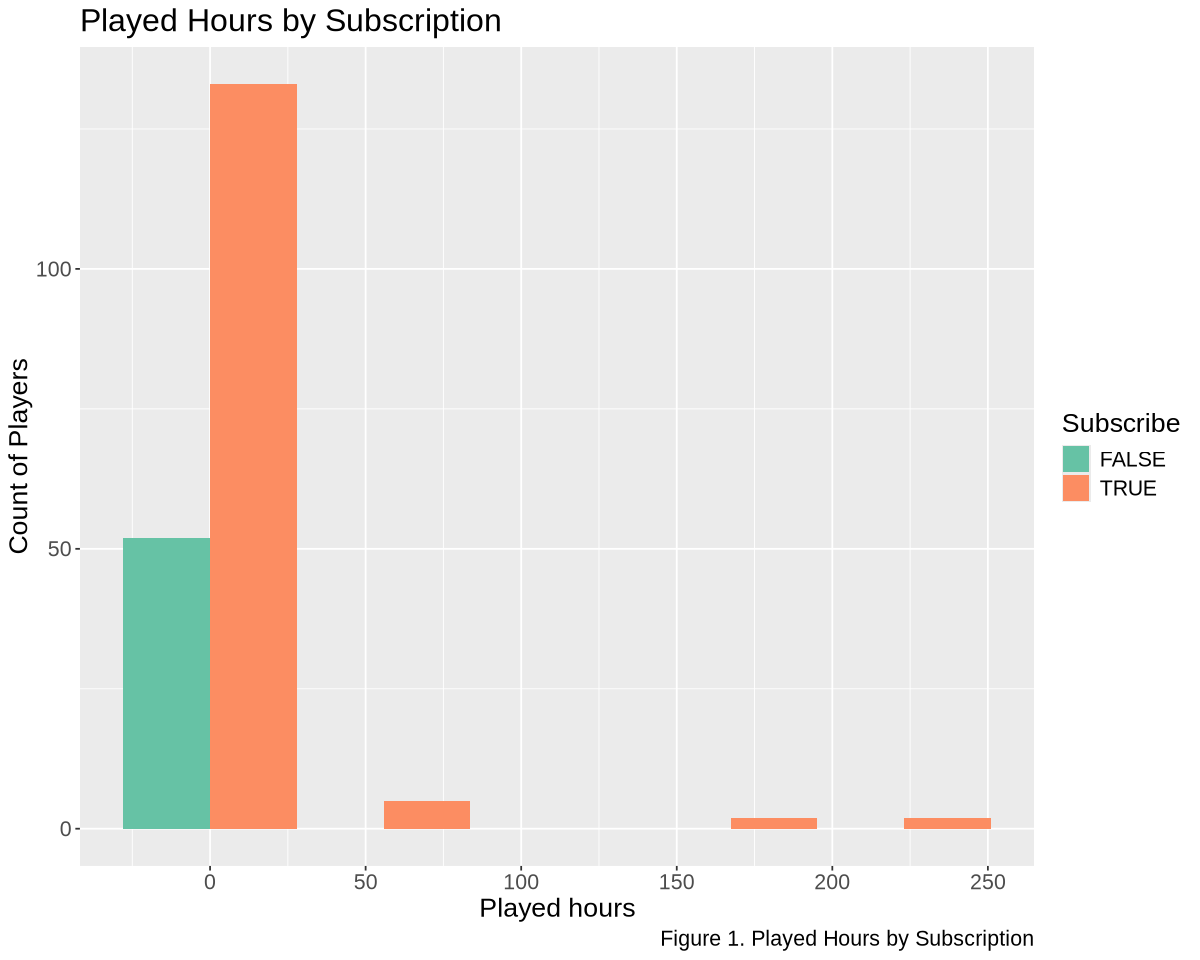

In [3]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = played_hours, fill = subscribe)) +
geom_histogram(position = "dodge", bins=5) +
labs(title = "Played Hours by Subscription",
       x = "Played hours", y = "Count of Players", fill = "Subscribe", caption = "Figure 1. Played Hours by Subscription") +
theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set2')

- **Figure 1:**  The histogram shows that the majority of players have low 
played hours, under 50 hours, and all of the non-subscribers are in this group. Additionally, the proportion 
of subscribers in this group is 75%. However, for the minority of players, those who play longer,
over 50 hours, subscription rates are significantly higher, nearly 100%.

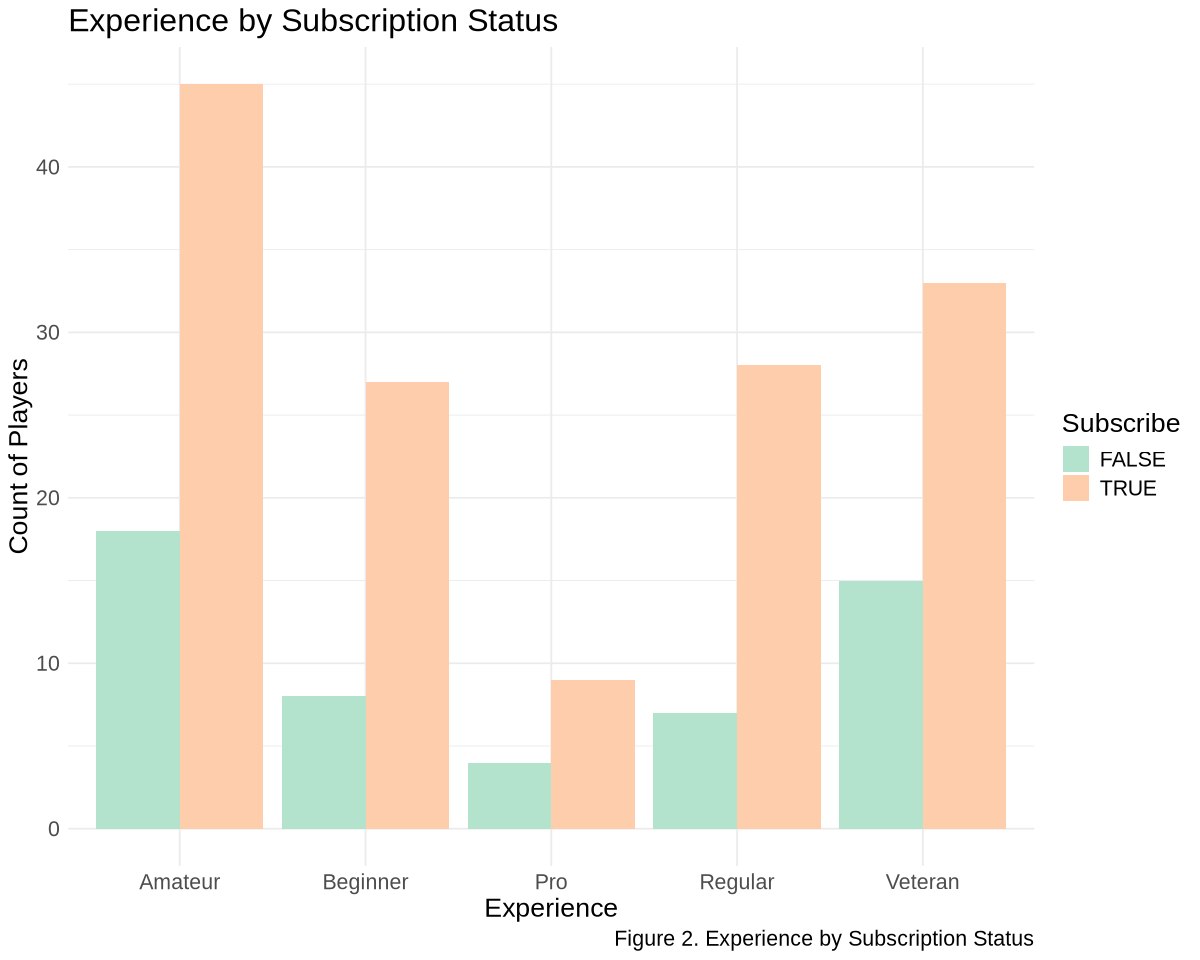

In [4]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = experience, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Experience by Subscription Status",
       x = "Experience", y = "Count of Players", fill = "Subscribe", caption = "Figure 2. Experience by Subscription Status") +
  theme_minimal() + theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Pastel2')

- **Figure 2:**  The chart compares player counts across experience levels by subscription status. In every category, subscribed players greatly outnumber non-subscribers, with the largest gap in the Amateur group and the smallest gap in the Pro group. Subscription numbers are also high among Veteran and Regular players, while the Pro group has the fewest players overall. Overall, subscribers consistently dominate across all experience levels. 

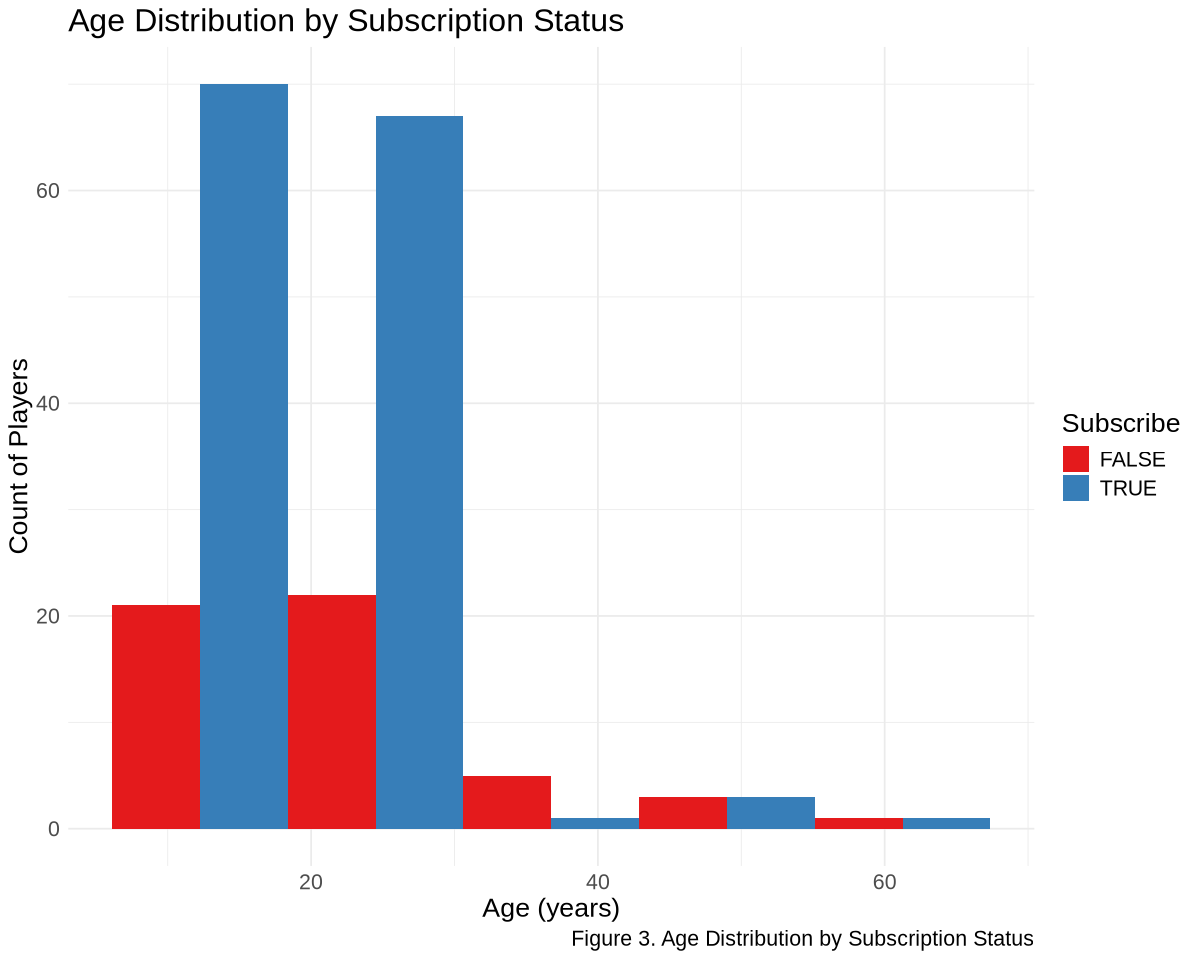

In [5]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = Age, fill = subscribe)) +
  geom_histogram(position = "dodge", bins = 5) +
  labs(title = "Age Distribution by Subscription Status",
       x = "Age (years)", y = "Count of Players", fill = "Subscribe", caption= "Figure 3. Age Distribution by Subscription Status") +
  theme_minimal() +theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set1')

- **Figure 3:** The bar graph demonstrates that most of the players, subscribers, and non-subscribers are below 30, with subscribers accounting for the highest proportion, while a minority of them are older, with the percentage of unsubscribe significantly rising. The number of non-subscribers in the age range 30-45 has the highest percentage compared to other age range.

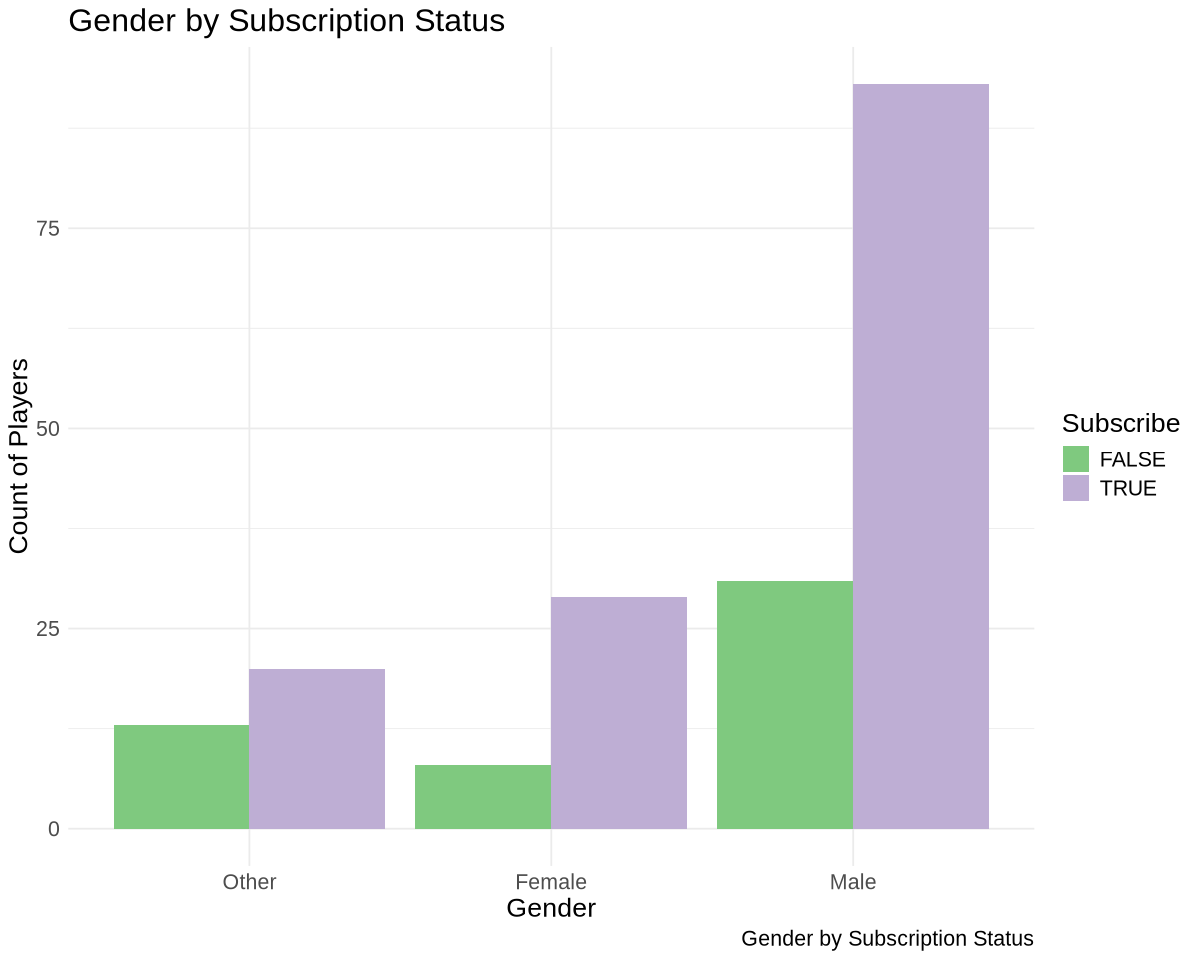

In [6]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = gender, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Gender by Subscription Status",
       x = "Gender", y = "Count of Players", fill = "Subscribe", caption = "Gender by Subscription Status") +
  theme_minimal() + theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Accent' ) 

- **Figure 4:** The bar graph indicates that all of the genders have a higher percentage of subscribers, with the highest proportion in "Male". Additionally, the number of players of "Male" is the highest, followed by "Female" and "Other".

**2. exploratory data analysis**:
From the exploratory data analysis, we could see that in Figure 1, all non-subscribers played below 50 hours, and in the higher-played-hour groups, all of them are subscribers. This pattern shows that the played hours is not a good predictor, since nearly everyone has low played hours, under 50, making subscribers and non-subscribers look almost the same. Only a few extreme outliers exist, which distort KNN distances. There is also no clear separation for classification in this case. Therefore, played hours is not a good predictor, so we just use "experience", "age", and "gender" as predictors in the analysis.   

**3. Methods**

## Gender(one hot encoding)

In [7]:
clean_players_gender <- clean_players|> mutate(gender = as.factor(gender)) #one hot encoding requires it to be in factor form
gender_matrix <- model.matrix(~ gender-1, data = clean_players) # ~gender -1 means I change gender into numeric form
gender_players <- clean_players |>
  bind_cols(as_tibble(gender_matrix)) # change from matrix form to table form
head(gender_players)

experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Pro,TRUE,30.3,Male,9,0,0,1
Veteran,TRUE,3.8,Male,17,0,0,1
Veteran,FALSE,0.0,Male,17,0,0,1
Amateur,TRUE,0.7,Female,21,0,1,0
Regular,TRUE,0.1,Male,21,0,0,1
Amateur,TRUE,0.0,Female,17,0,1,0


In [8]:
set.seed(1123) # set. seed function makes sure you will obtain the exact same sequence of "random" numbers every time you run the code, the number inside is arbitary
# split
gender_split <- initial_split(gender_players, prop = 0.75, strata = subscribe)
gender_train <- training(gender_split)
gender_test <- testing(gender_split)

# recipe
gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [9]:
# specification
gender_spec_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

# k-values
gender_ks <- tibble(neighbors = 1:20)

# v-fold
gender_vfold <- vfold_cv(gender_train, v = 5, strata = subscribe)

In [10]:
# workflow with validation
gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec_tune) |>
  tune_grid(resamples = gender_vfold, grid = gender_ks) 

# accuracy
gender_tune_accuracy <- gender_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(gender_tune_accuracy)

neighbors,mean
<int>,<dbl>
17,0.4203777
18,0.4203777
19,0.3996880
20,0.3996880
13,0.3789984
14,0.3789984


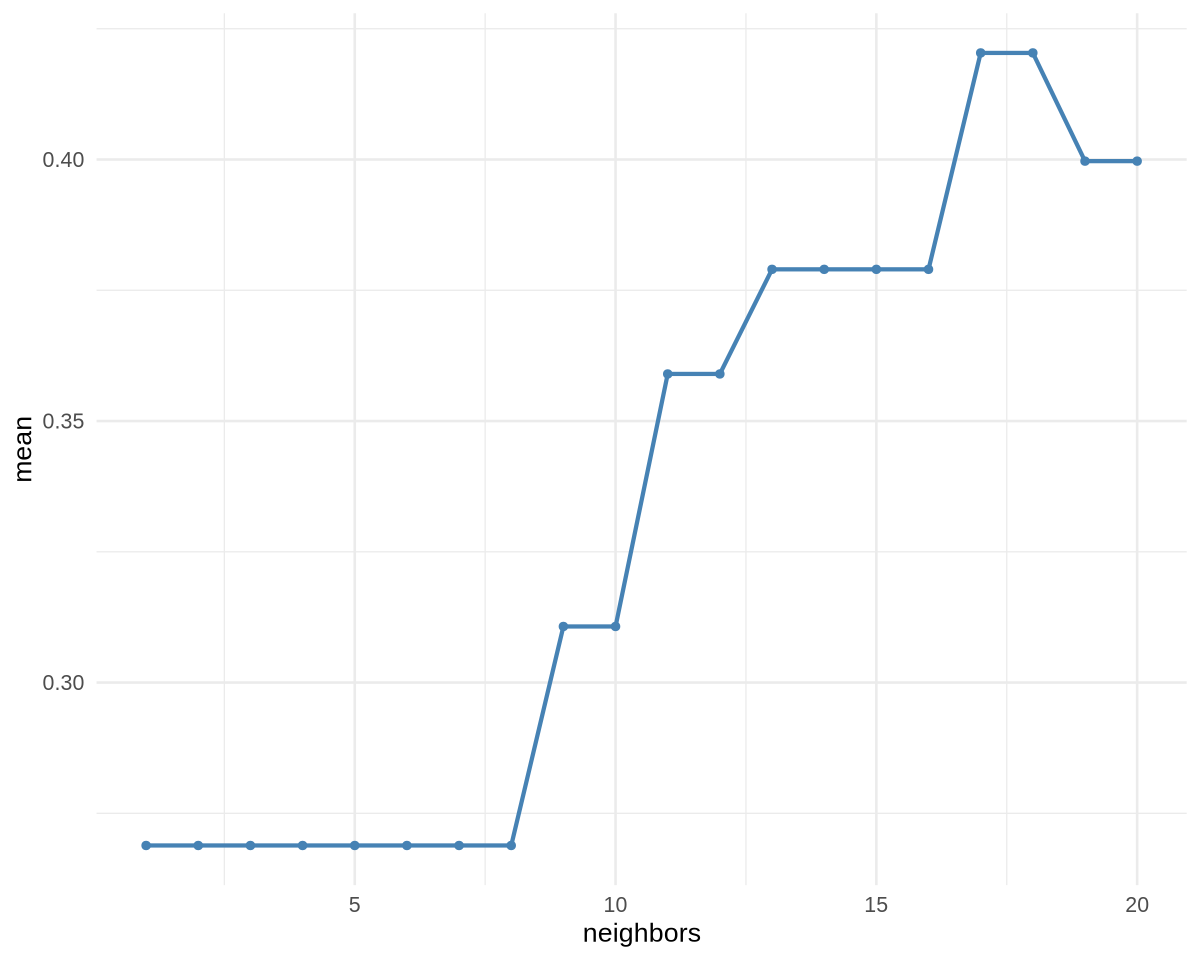

In [11]:
ggplot(gender_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  theme_minimal(base_size = 16)

In [12]:
gender_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 17) |>
  set_engine("kknn") |>
  set_mode("classification")

gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [13]:
# workflow with validation
gender_vfold <- vfold_cv(gender_test, v = 5, strata = subscribe)

gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec) |>
  fit(data = gender_train)

In [14]:
gender_test_predictions <- predict(gender_fit, gender_test) |>
  bind_cols(gender_test)

In [15]:
confusion_gender <- data.frame(
  truth = gender_test_predictions$subscribe,
  estimate = gender_test_predictions$.pred_class)

confusion_gender_result <- conf_mat(
  data = confusion_gender,
  truth = "truth",
  estimate = "estimate")

confusion_gender_result

          Truth
Prediction FALSE TRUE
     FALSE    11   31
     TRUE      2    5

In [16]:
gender_table <- confusion_gender_result$table
gender_table_tidy <- as_tibble(gender_table)
colnames(gender_table_tidy) <- c("Prediction", "Truth", "n")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


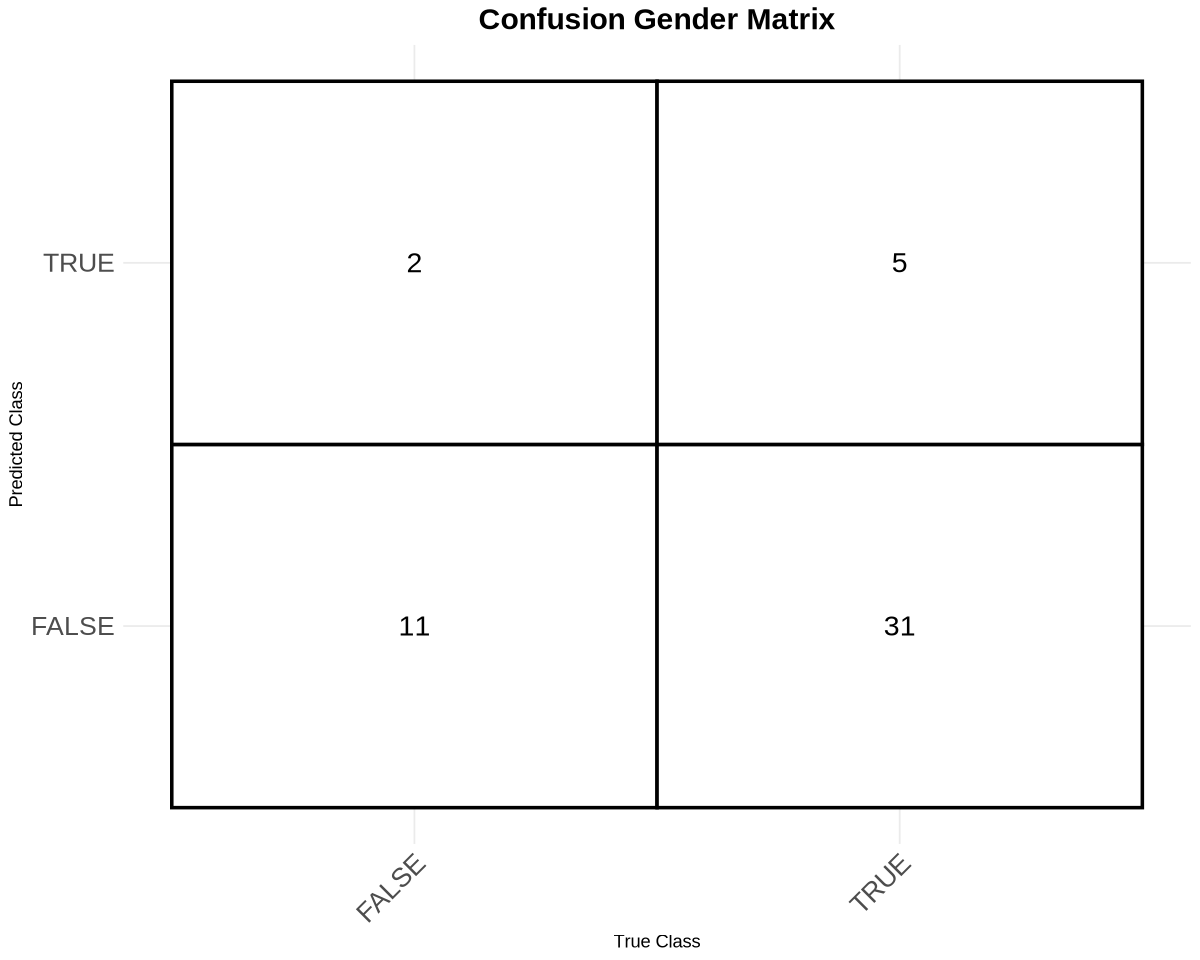

In [17]:
ggplot(gender_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + 
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Gender Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [18]:
gender_accuracy <-gender_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
gender_accuracy

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.3265306


In [67]:
gender_precision <- precision(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
gender_precision

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.7142857


In [68]:
gender_recall <- recall(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
gender_recall

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.1388889


## Age (ordinal encoding)

In [21]:
head(clean_players)

experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


In [22]:
set.seed(1123)
age_split <- initial_split(clean_players, prop = 0.75, strata = subscribe) 
age_train <- training(age_split)
age_test <- testing(age_split)

In [23]:
age_recipe <- recipe(subscribe ~ Age, data = age_train) |>
  step_dummy(all_nominal(), -all_outcomes()) |>  # Convert categorical variables to dummy variables, ensure that it's all numeric before scaling
  step_scale(all_numeric(), -all_outcomes())

In [69]:
age_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

age_ks <- tibble(neighbors = 1:20)

In [70]:
age_tune_vfold <- vfold_cv(age_train, v = 5, strata = subscribe)

In [71]:

age_tune_fit <- workflow() |>
  add_recipe(age_recipe) |>
  add_model(age_tune) |>
  tune_grid(resamples = age_tune_vfold, grid = age_ks) 

In [72]:

age_tune_accuracy <- age_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(age_tune_accuracy)

neighbors,mean
<int>,<dbl>
19,0.6407718
20,0.6407718
17,0.5177833
18,0.5177833
3,0.4692282
7,0.4623481


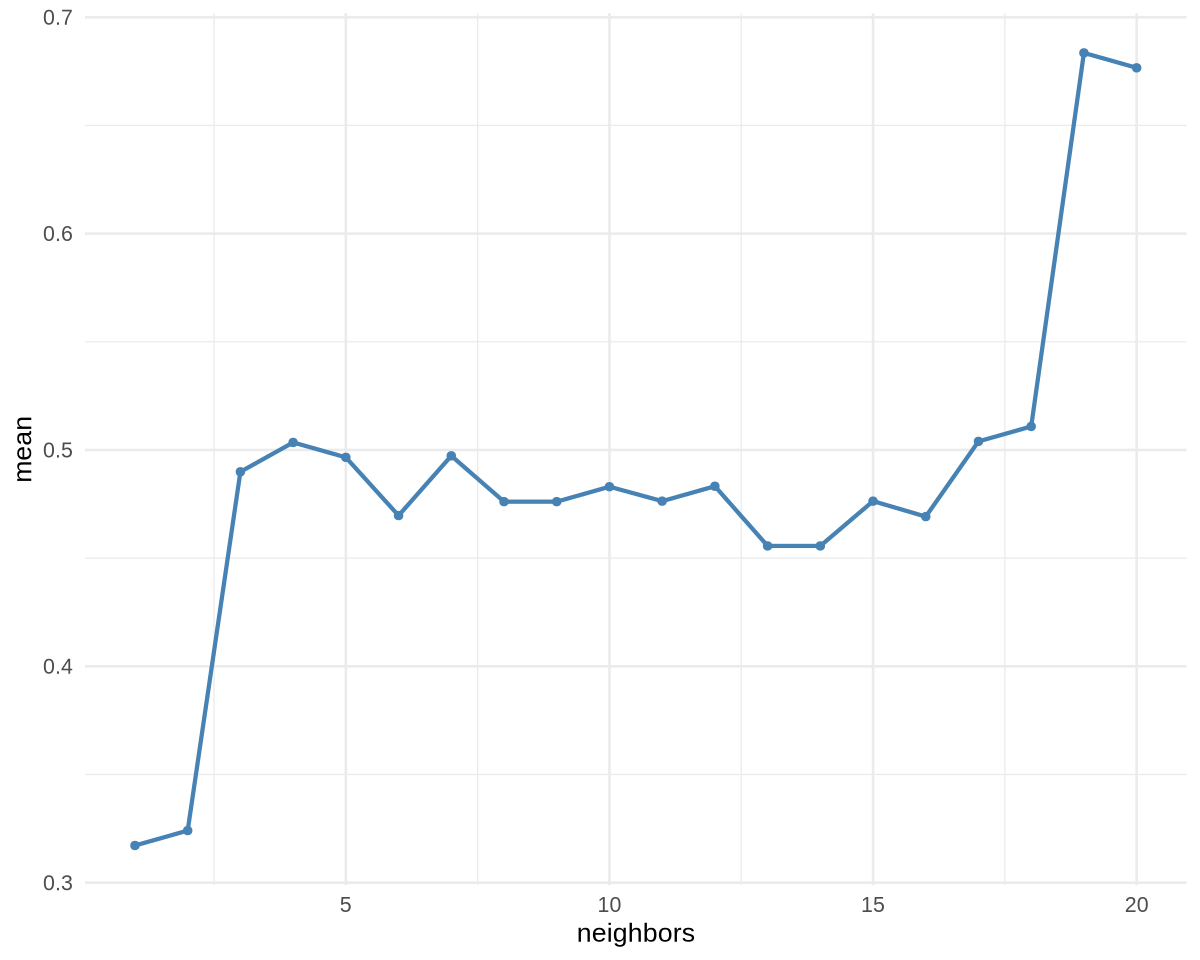

In [28]:
ggplot(age_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  theme_minimal(base_size = 16)

In [29]:
age_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 19) |>
  set_engine("kknn") |>
  set_mode("classification")

In [30]:
age_fit <- workflow() |>
  add_recipe(age_recipe) |>
  add_model(age_spec) |>
 fit(data = age_train)

age_test_predictions <- predict(age_fit, age_test) |>
  bind_cols(age_test)
head(age_test_predictions)

.pred_class,experience,subscribe,played_hours,gender,Age
<fct>,<chr>,<fct>,<dbl>,<fct>,<dbl>
FALSE,Veteran,TRUE,3.8,Male,17
TRUE,Regular,TRUE,0.1,Male,21
TRUE,Amateur,FALSE,0.0,Male,21
TRUE,Amateur,TRUE,0.1,Male,47
FALSE,Veteran,TRUE,0.0,Other,17
FALSE,Amateur,TRUE,48.4,Female,17


In [31]:
confusion_age <- data.frame(
  truth = age_test_predictions$subscribe,
  estimate = age_test_predictions$.pred_class)

confusion_age_result <- conf_mat(
  data = confusion_age,
  truth = "truth",
  estimate = "estimate")

confusion_age_result

          Truth
Prediction FALSE TRUE
     FALSE     5   14
     TRUE      8   22

In [32]:
age_table <- confusion_age_result$table
age_table_tidy <- as_tibble(age_table)
colnames(age_table_tidy) <- c("Prediction", "Truth", "n")

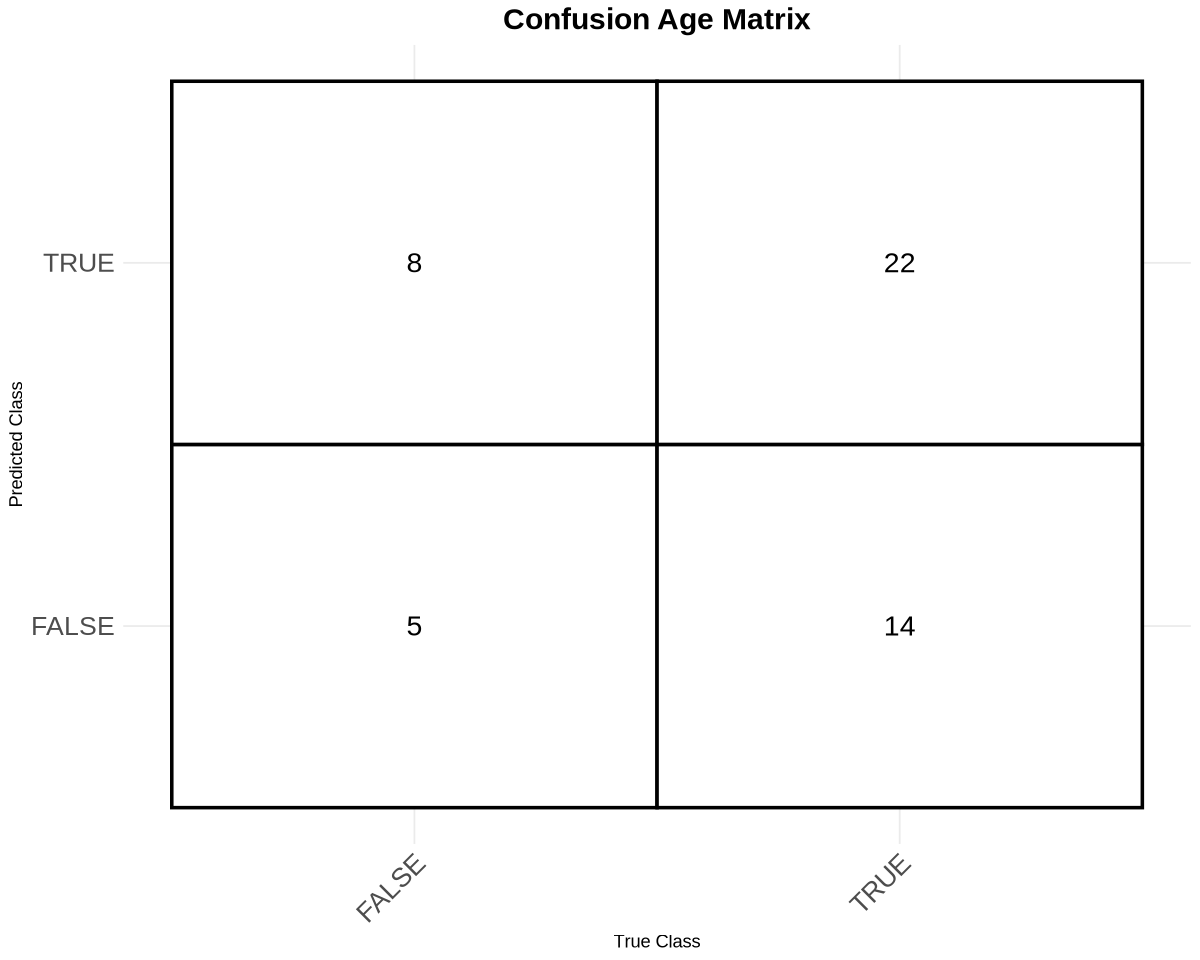

In [33]:
ggplot(age_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + #black borders
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Age Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [34]:
age_accuracy <-age_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
age_accuracy

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.5510204


In [73]:
age_precision <-precision(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
age_precision

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.7142857


In [74]:
age_recall <- recall(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
age_recall

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.1388889


## Experience (ordinal encoding)

In [37]:
experience_encoded = factor(clean_players$experience,
  levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"),
  ordered = TRUE)
experience_numeric = as.numeric(experience_encoded)

In [38]:
clean_experience_players <- clean_players |> mutate( experience_numeric = experience_numeric)
head(clean_experience_players)

experience,subscribe,played_hours,gender,Age,experience_numeric
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
Pro,TRUE,30.3,Male,9,5
Veteran,TRUE,3.8,Male,17,4
Veteran,FALSE,0.0,Male,17,4
Amateur,TRUE,0.7,Female,21,2
Regular,TRUE,0.1,Male,21,3
Amateur,TRUE,0.0,Female,17,2


In [39]:
set.seed(1123)
experience_split <- initial_split(clean_experience_players, prop = 0.75, strata = subscribe)
experience_train <- training(experience_split)
experience_test <- testing(experience_split)

experience_recipe <- recipe(subscribe ~ experience_numeric, data = clean_experience_players) |>
step_dummy(all_nominal(), -all_outcomes()) |>  
  step_scale(all_numeric(), -all_outcomes())

experience_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

experience_ks <- tibble(neighbors = 1:20)

In [40]:
experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

# workflow with validation
experience_tune_fit <- workflow() |>
  add_recipe(experience_recipe) |>
  add_model(experience_tune) |>
  tune_grid(resamples = experience_vfold, grid = experience_ks) 
 
# accuracy
experience_tune_accuracy <- experience_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(experience_tune_accuracy)

neighbors,mean
<int>,<dbl>
20,0.5457964
19,0.5379475
18,0.5108210
11,0.5103612
12,0.5103612
17,0.4965353


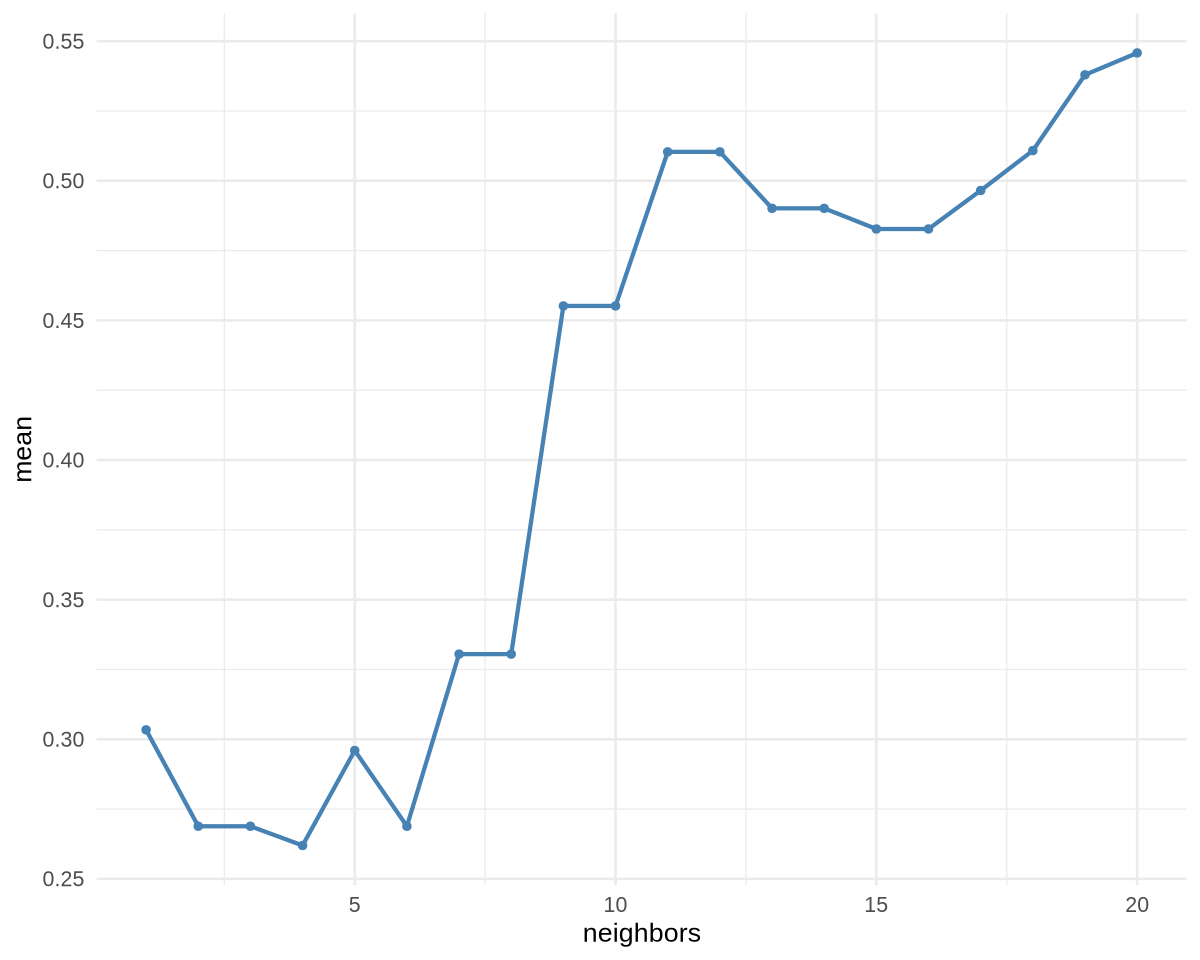

In [41]:
ggplot(experience_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  theme_minimal(base_size = 16)

In [42]:
experience_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 20) |>
  set_engine("kknn") |>
  set_mode("classification")

In [43]:
experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

In [44]:
experience_fit <- workflow() |>
  add_recipe(experience_recipe) |>
  add_model(experience_spec) |>
  fit(data = experience_train)

In [45]:
experience_test_predictions <- predict(experience_fit, experience_test) |>
  bind_cols(experience_test)
head(experience_test_predictions)

.pred_class,experience,subscribe,played_hours,gender,Age,experience_numeric
<fct>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
FALSE,Veteran,TRUE,3.8,Male,17,4
TRUE,Regular,TRUE,0.1,Male,21,3
FALSE,Amateur,FALSE,0.0,Male,21,2
FALSE,Amateur,TRUE,0.1,Male,47,2
FALSE,Veteran,TRUE,0.0,Other,17,4
FALSE,Amateur,TRUE,48.4,Female,17,2


In [46]:
confusion_experience <- data.frame(
  truth = experience_test_predictions$subscribe,
  estimate = experience_test_predictions$.pred_class)

confusion_experience_result <- conf_mat(
  data = confusion_experience,
  truth = "truth",
  estimate = "estimate")

confusion_experience_result

          Truth
Prediction FALSE TRUE
     FALSE     7   20
     TRUE      6   16

In [47]:
experience_table <- confusion_experience_result$table
experience_table_tidy <- as_tibble(experience_table)
colnames(experience_table_tidy) <- c("Prediction", "Truth", "n")

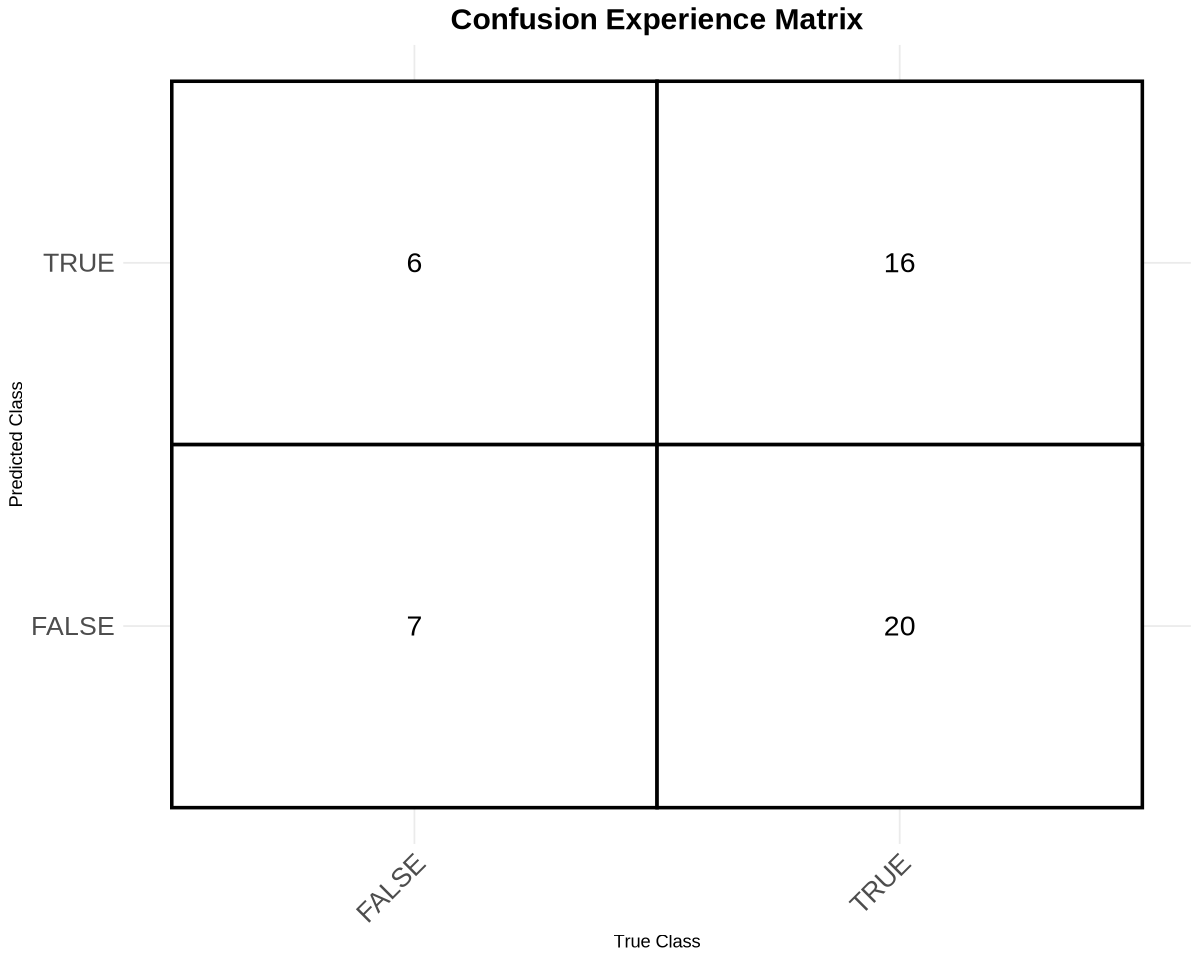

In [48]:
ggplot(experience_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + #black borders
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Experience Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [49]:
experience_accuracy <- experience_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
experience_accuracy

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.4693878


In [75]:
experience_precision <-precision(data = confusion_experience,truth = "truth", estimate = "estimate", event_level = "second")
experience_precision

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.7272727


In [77]:
experience_recall <- recall(data = confusion_experience,truth = "truth", estimate = "estimate", event_level = "second")
experience_recall

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.4444444


## Age and Experience

In [52]:
experience_encoded = factor(clean_players$experience,
  levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"),
  ordered = TRUE)
experience_numeric = as.numeric(experience_encoded)

age_experience_players <- clean_players |> select(-gender,-played_hours) |> 
mutate( experience_numeric = experience_numeric) |> 
select(-experience)
head(age_experience_players)

subscribe,Age,experience_numeric
<fct>,<dbl>,<dbl>
TRUE,9,5
TRUE,17,4
FALSE,17,4
TRUE,21,2
TRUE,21,3
TRUE,17,2


In [53]:
set.seed(1123)
age_experience_split <- initial_split(age_experience_players, prop = 0.75, strata = subscribe)
age_experience_train <- training(age_experience_split)
age_experience_test <- testing(age_experience_split)

In [54]:
set.seed(1123)

age_experience_recipe <- recipe(subscribe ~ experience_numeric + Age , data = age_experience_train ) |>
step_dummy(all_nominal(), -all_outcomes()) |>  
  step_scale(all_numeric(), -all_outcomes())

In [55]:
age_experience_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

age_experience_ks <- tibble(neighbors = 1:20)

In [56]:
age_experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

age_experience_tune_fit <- workflow() |>
  add_recipe(age_experience_recipe) |>
  add_model(age_experience_tune) |>
  tune_grid(resamples = age_experience_vfold, grid = age_experience_ks) 
 
age_experience_tune_accuracy <- age_experience_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(age_experience_tune_accuracy)

neighbors,mean
<int>,<dbl>
19,0.7382759
20,0.7249425
13,0.7178161
15,0.7178161
17,0.7109195
18,0.7109195


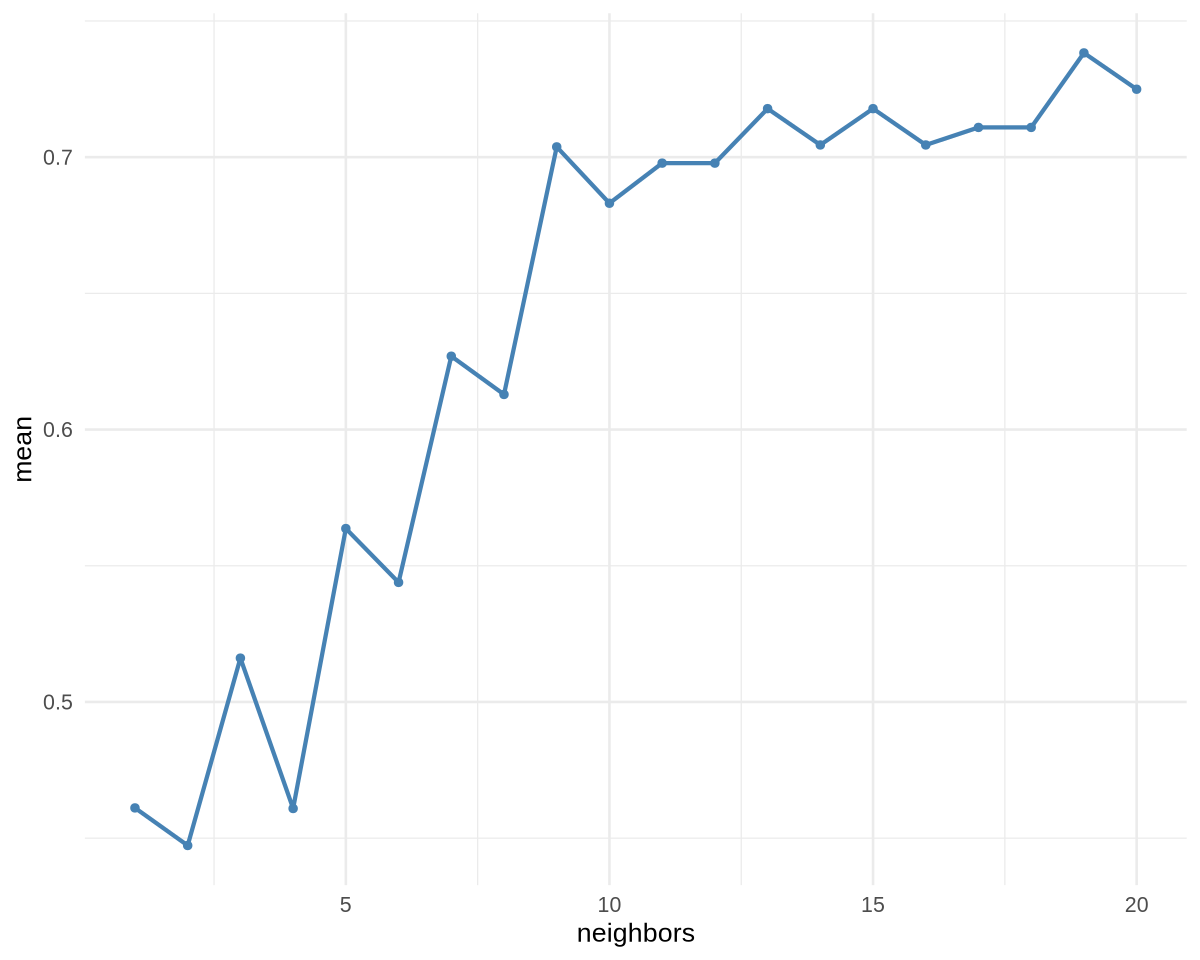

In [57]:
ggplot(age_experience_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  theme_minimal(base_size = 16)

In [58]:
age_experience_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 19) |>
  set_engine("kknn") |>
  set_mode("classification")

In [59]:
age_experience_vfold <- vfold_cv(age_experience_train, v = 5, strata = subscribe)

age_experience_fit <- workflow() |>
  add_recipe(age_experience_recipe) |>
  add_model(age_experience_spec) |>
  fit(data = age_experience_train)

In [60]:
age_experience_test_predictions <- predict(age_experience_fit, age_experience_test) |>
  bind_cols(age_experience_test)
head(age_experience_test_predictions)

.pred_class,subscribe,Age,experience_numeric
<fct>,<fct>,<dbl>,<dbl>
TRUE,TRUE,17,4
TRUE,TRUE,21,3
TRUE,FALSE,21,2
FALSE,TRUE,47,2
TRUE,TRUE,17,4
TRUE,TRUE,17,2


In [61]:
confusion_age_experience <- data.frame(
  truth = age_experience_test_predictions$subscribe,
  estimate = age_experience_test_predictions$.pred_class)

confusion_age_experience_result <- conf_mat(
  data = confusion_age_experience,
  truth = "truth",
  estimate = "estimate")

confusion_age_experience_result

          Truth
Prediction FALSE TRUE
     FALSE     2    2
     TRUE     11   34

In [62]:
age_experience_table <- confusion_age_experience_result$table
age_experience_table_tidy <- as_tibble(age_experience_table)
colnames(age_experience_table_tidy) <- c("Prediction", "Truth", "n")

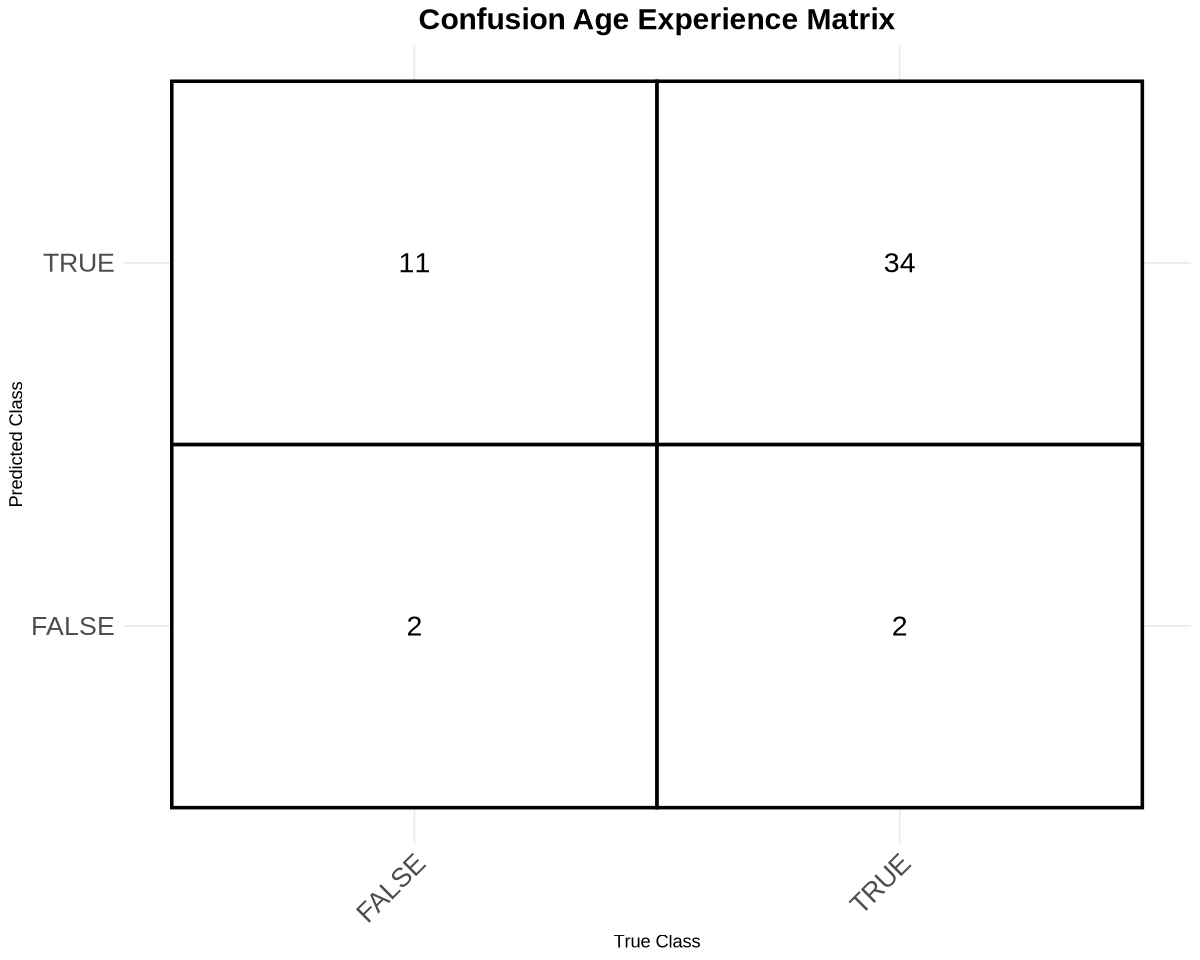

In [63]:
ggplot(age_experience_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + 
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Age Experience Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [64]:
age_experience_accuracy <- age_experience_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
age_experience_accuracy

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7346939


In [78]:
age_experience_precision <-precision(data = confusion_age_experience,truth = "truth", estimate = "estimate", event_level = "second")
age_experience_precision

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.7555556


In [79]:
experience_recall <- recall(data = confusion_age_experience,truth = "truth", estimate = "estimate", event_level = "second")
experience_recall

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.9444444


## Discussion

summarize what you found(accuracy)
discuss whether this is what you expected to find
discuss what impact could such findings have
discuss what future questions could this lead to

## Reference 